In [1]:
# Colab / fresh environment: install the module (builds the C++ core, takes a few minutes the first time)
try:
    import sensor_fusion
except ImportError:
    %pip install -q git+https://github.com/Rudip1/learn-sensor-fusion

# 3 · GNSS quality: DOP, fix types, satellite geometry, motion vs standstill

**Recap** ([theory](../../1_theory/03_gnss_quality.md)). With range noise $\sigma_\rho$ the fix covariance
is $\sigma_\rho^2\mathbf Q$, $\mathbf Q=(\mathbf G^\top\mathbf W\mathbf G)^{-1}$; in ENU the rows of
$\mathbf G$ come straight from azimuth and elevation (3.1), and HDOP/VDOP/PDOP are square roots of sums of
its diagonal (3.3). Fix-type codes differ between GGA, GSA, RMC and ROS. A static log measures
*precision* (σ, DRMS, CEP, R95, confidence ellipse (3.6)–(3.7)), not accuracy. Motion is detected with a
$\chi^2$ test on displacements (3.8) — whose noise $\sigma_d(\tau)$ must be calibrated, because GNSS errors
are correlated in time (3.9).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sensor_fusion as sf
from sensor_fusion import geo, gnss, nmea
from sensor_fusion.plotting import SERIES, use_style

use_style()


def load_log(name):
    epochs = nmea.parse_log_file(str(sf.data.path("gnss/" + name))).epochs
    a = sf.tables.epochs_to_arrays(epochs)
    v = a["fix_quality"] > 0
    h = a["alt_msl"] + a["geoid_sep"]
    ltp = geo.LocalTangentPlane(a["lat"][v][0], a["lon"][v][0], h[v][0])
    a["enu"] = np.full((len(v), 3), np.nan)
    a["enu"][v] = ltp.geodetic_to_enu(a["lat"][v], a["lon"][v], h[v])
    return a, epochs


static, static_epochs = load_log("nmea_log1.nmea")
walk, walk_epochs = load_log("nmea_log2.nmea")

## 1. DOP from azimuth and elevation

### ✏️ Exercise 1
Implement `my_dop(az_deg, el_deg)` returning `(pdop, hdop, vdop)` with eqs. (3.1)–(3.3) (unit weights).

In [3]:
def my_dop(az_deg, el_deg):
    ### BEGIN SOLUTION
    az, el = np.radians(az_deg), np.radians(el_deg)
    G = np.column_stack([-np.cos(el) * np.sin(az), -np.cos(el) * np.cos(az), -np.sin(el), np.ones_like(az)])
    Q = np.linalg.inv(G.T @ G)
    return np.sqrt(Q[0, 0] + Q[1, 1] + Q[2, 2]), np.sqrt(Q[0, 0] + Q[1, 1]), np.sqrt(Q[2, 2])
    ### END SOLUTION

In [4]:
# ring of 6 at 20 degrees plus the zenith: compare with the closed form (3.5)
n, eps = 6, np.radians(20)
az = np.r_[np.linspace(0, 360, n, endpoint=False), 0.0]
el = np.r_[np.full(n, 20.0), 90.0]
pdop, hdop, vdop = my_dop(az, el)
s, c = np.sin(eps), np.cos(eps)
assert np.isclose(hdop, 2 / (c * np.sqrt(n)))
assert np.isclose(vdop, np.sqrt((n + 1) / (n * (1 - s) ** 2)))
d = gnss.compute_dop(az, el)
assert np.allclose([pdop, hdop, vdop], [d.pdop, d.hdop, d.vdop])
print(f"✅ ring + zenith: HDOP {hdop:.3f}, VDOP {vdop:.3f} — matches (3.5) and the C++ code")

✅ ring + zenith: HDOP 0.869, VDOP 1.642 — matches (3.5) and the C++ code


## 2. The receiver's DOP against the geometry in its own log

For every epoch take the satellites listed in GSA, look up their azimuth/elevation in the latest GSV group,
and recompute PDOP.

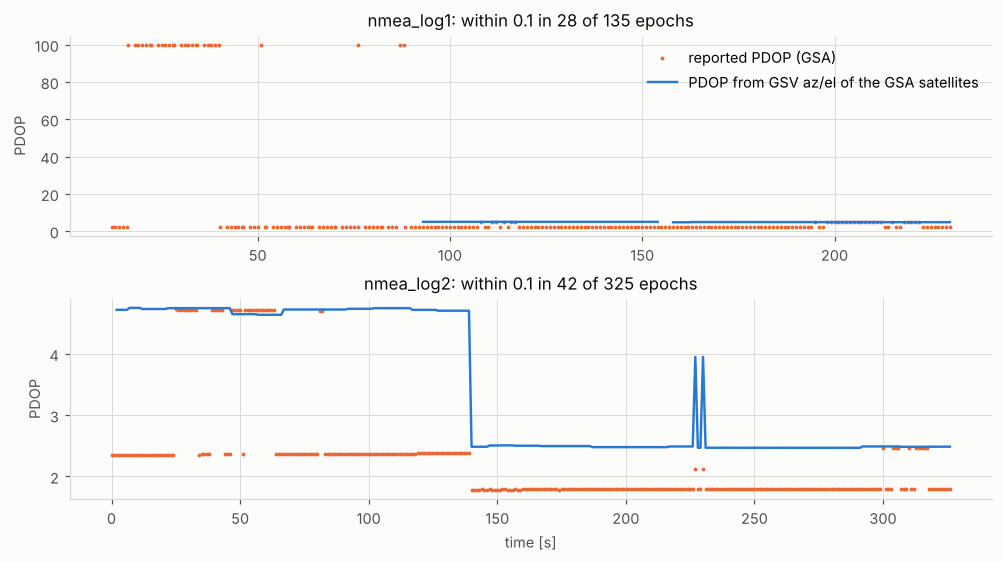

walk epoch 20: reported VDOP 0.97, GPS-only geometry gives VDOP 3.79


In [5]:
def dop_series(a, epochs):
    sky = sf.tables.sky_per_epoch(epochs)
    out = np.full((len(epochs), 3), np.nan)
    for i, e in enumerate(epochs):
        u = sky[i]["used"]
        if u.sum() >= 4 and u.sum() == len(e.used_prns):
            dd = gnss.compute_dop(sky[i]["azimuth_deg"][u], sky[i]["elevation_deg"][u])
            out[i] = dd.pdop, dd.hdop, dd.vdop
    return out


fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=False, constrained_layout=True)
for ax, (name, a, ep) in zip(axes, [("nmea_log1", static, static_epochs), ("nmea_log2", walk, walk_epochs)]):
    calc = dop_series(a, ep)
    t = a["t"] - a["t"][0]
    ax.plot(t, a["pdop"], ".", ms=3, color=SERIES[1], label="reported PDOP (GSA)")
    ax.plot(t, calc[:, 0], "-", color=SERIES[0], label="PDOP from GSV az/el of the GSA satellites")
    ok = ~np.isnan(calc[:, 0]) & ~np.isnan(a["pdop"])
    agree = np.abs(calc[ok, 0] - a["pdop"][ok]) < 0.1
    ax.set_title(f"{name}: within 0.1 in {agree.sum()} of {ok.sum()} epochs")
    ax.set_ylabel("PDOP")
axes[1].set_xlabel("time [s]"); axes[0].legend()
plt.show()
calc_walk = dop_series(walk, walk_epochs)
k = 20
print(f"walk epoch {k}: reported VDOP {walk['vdop'][k]}, GPS-only geometry gives VDOP {calc_walk[k, 2]:.2f}")

Two DOP sets alternate: one matches the GPS satellites the receiver lists, the other is lower than any
subset of them could give. A receiver that also uses satellites it does not list in `GP` sentences (another
constellation, SBAS) would behave like this; the logs do not say. **A DOP is only meaningful together with
the satellite list it was computed from.**

## 3. Fix types in the data

In [6]:
for name, a in [("nmea_log1", static), ("nmea_log2", walk)]:
    q, cnt = np.unique(a["fix_quality"], return_counts=True)
    ft, cnt2 = np.unique(a["fix_type"], return_counts=True)
    print(name, "| GGA quality:", {gnss.gga_quality_name(int(x)): int(y) for x, y in zip(q, cnt)},
          "| GSA fix type:", {gnss.gsa_fix_type_name(int(x)): int(y) for x, y in zip(ft, cnt2)})

for run in (1, 2, 3):
    fix = sf.io.load_navsatfix(f"parking_lot/run{run}_fix.csv")
    for st in np.unique(fix["status"]):
        for small in (True, False):
            m = (fix["status"] == st) & ((fix["var_e"] < 1.0) == small)
            if m.any():
                print(f"parking lot run {run}: {gnss.navsat_status_name(int(st)):16s} {m.sum():4d} fixes "
                      f"(indices {np.flatnonzero(m)[0]}..{np.flatnonzero(m)[-1]}), "
                      f"horizontal variance {fix['var_e'][m].min():.4g} .. {fix['var_e'][m].max():.4g} m^2")

nmea_log1 | GGA quality: {'invalid': 12, 'GPS (standard positioning)': 219} | GSA fix type: {'no fix': 12, '2D': 77, '3D': 142}
nmea_log2 | GGA quality: {'GPS (standard positioning)': 327} | GSA fix type: {'3D': 327}
parking lot run 1: STATUS_GBAS_FIX    48 fixes (indices 614..661), horizontal variance 0.0002958 .. 0.0004928 m^2
parking lot run 1: STATUS_GBAS_FIX   614 fixes (indices 0..613), horizontal variance 15.05 .. 45.7 m^2
parking lot run 2: STATUS_GBAS_FIX    33 fixes (indices 0..32), horizontal variance 15.05 .. 33.64 m^2
parking lot run 3: STATUS_SBAS_FIX    66 fixes (indices 71..327), horizontal variance 0.01 .. 0.04452 m^2
parking lot run 3: STATUS_GBAS_FIX   359 fixes (indices 0..424), horizontal variance 13.25 .. 71.23 m^2


## 4. Precision of the static log

### ✏️ Exercise 2
From the east/north positions `en` (an `(n, 2)` array) compute σ_E, σ_N, DRMS, CEP and R95 as in (3.6).
Use `np.std(..., ddof=1)` and `np.percentile`. The check compares with `gnss.precision_stats`.

In [7]:
v3 = (static["fix_quality"] > 0) & (static["fix_type"] == 3)
en = static["enu"][v3][:, :2]

### BEGIN SOLUTION
sig_e, sig_n = en.std(axis=0, ddof=1)
drms = np.hypot(sig_e, sig_n)
r = np.linalg.norm(en - en.mean(axis=0), axis=1)
cep, r95 = np.percentile(r, 50), np.percentile(r, 95)
### END SOLUTION
print(f"σ_E {sig_e:.2f} m, σ_N {sig_n:.2f} m, DRMS {drms:.2f} m, CEP {cep:.2f} m, R95 {r95:.2f} m")

σ_E 3.37 m, σ_N 3.31 m, DRMS 4.72 m, CEP 4.41 m, R95 7.56 m


In [8]:
ps = gnss.precision_stats(en)
assert np.allclose([sig_e, sig_n, drms, cep, r95], [ps.sigma_east, ps.sigma_north, ps.drms, ps.cep50, ps.r95])
print("✅ precision statistics match")
all_fixes = static["enu"][static["fix_quality"] > 0][:, :2]
pa = gnss.precision_stats(all_fixes)
print(f"3D fixes only : σ_E {ps.sigma_east:.2f} m, σ_N {ps.sigma_north:.2f} m ({ps.count} fixes)")
print(f"incl. 2D fixes: σ_E {pa.sigma_east:.2f} m, σ_N {pa.sigma_north:.2f} m ({pa.count} fixes)")
e95 = gnss.error_ellipse(ps.covariance, 0.95)
print("95 % ellipse:", e95)

✅ precision statistics match
3D fixes only : σ_E 3.37 m, σ_N 3.31 m (142 fixes)
incl. 2D fixes: σ_E 4.09 m, σ_N 5.15 m (219 fixes)
95 % ellipse: ErrorEllipse(semi_major=11.0869, semi_minor=3.2821, angle_deg=-44.37)


## 5. Motion vs standstill

### ✏️ Exercise 3 — calibrate $\sigma_d(\tau)$
On the static 3D fixes, compute for each lag τ the per-axis RMS of the displacement between fixes τ
seconds apart: $\sigma_d(\tau) = \sqrt{\tfrac12\,\mathrm{mean}\,\lVert\mathbf p(t+\tau)-\mathbf p(t)\rVert^2}$
(3.9). Fixes come at 1 Hz with gaps; only use pairs whose time difference equals τ within 0.5 s.

In [9]:
t_static = static["t"][v3]


def sigma_d(t, en, lag):
    ### BEGIN SOLUTION
    j = np.searchsorted(t, t + lag)
    ok = j < len(t)
    ok[ok] &= np.abs(t[j[ok]] - t[ok] - lag) < 0.5
    d = en[j[ok]] - en[ok]
    return np.sqrt(np.mean(np.sum(d**2, axis=1)) / 2)
    ### END SOLUTION


lags = [1, 2, 5, 10, 20, 60]
sd = [sigma_d(t_static, en, L) for L in lags]
print("σ_d(τ):", ", ".join(f"{L} s: {x:.2f} m" for L, x in zip(lags, sd)))

σ_d(τ): 1 s: 0.30 m, 2 s: 0.52 m, 5 s: 1.13 m, 10 s: 2.01 m, 20 s: 3.45 m, 60 s: 6.24 m


In [10]:
assert sd[0] < sd[2] < sd[-1]
assert 0.9 < sd[2] < 1.4
print(f"✅ white noise would predict σ_d = √2·σ ≈ {np.sqrt(2) * ps.drms / np.sqrt(2):.2f} m at every lag")

✅ white noise would predict σ_d = √2·σ ≈ 4.72 m at every lag


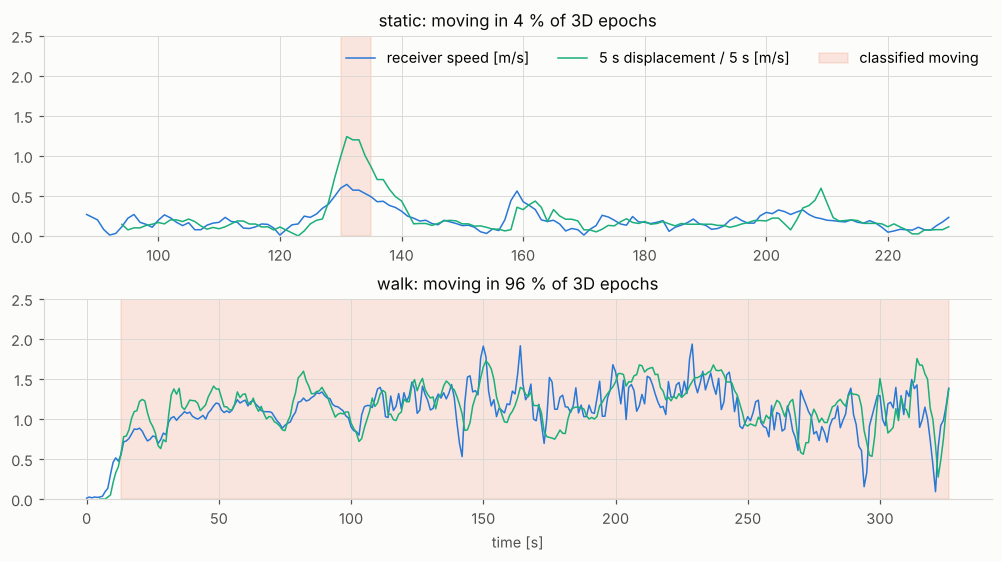

In [11]:
params = gnss.MotionParams()
params.window_s = 5.0
params.sigma_displacement_m = sd[2]
fig, axes = plt.subplots(2, 1, figsize=(9, 5), constrained_layout=True)
for ax, (name, a) in zip(axes, [("static", static), ("walk", walk)]):
    v = (a["fix_quality"] > 0) & (a["fix_type"] == 3)
    res = gnss.classify_motion(a["t"][v], a["enu"][v][:, :2], a["speed"][v], params)
    t = a["t"][v] - a["t"][0]
    ax.plot(t, a["speed"][v], color=SERIES[0], lw=1, label="receiver speed [m/s]")
    ax.plot(t, res.displacement_speed, color=SERIES[2], lw=1, label="5 s displacement / 5 s [m/s]")
    ax.fill_between(t, 0, 2.5, where=np.array(res.moving), color=SERIES[1], alpha=0.15, label="classified moving")
    ax.set_ylim(0, 2.5); ax.set_title(f"{name}: moving in {100 * np.mean(res.moving):.0f} % of 3D epochs")
axes[0].legend(ncol=3, loc="upper right"); axes[1].set_xlabel("time [s]")
plt.show()

## 6. 🔨 Break it

### 🔨 6.1 Assume white noise
Use $\sigma_d = \sqrt2\,\sigma$ with the static σ (≈3.4 m) — the "obvious" choice.

In [12]:
p_white = gnss.MotionParams()
p_white.window_s = 5.0
p_white.sigma_displacement_m = np.sqrt(2) * ps.sigma_east
vw = (walk["fix_quality"] > 0) & (walk["fix_type"] == 3)
res = gnss.classify_motion(walk["t"][vw], walk["enu"][vw][:, :2], None, p_white)
print(f"white-noise threshold: the walk is 'moving' in {100 * np.mean(res.moving):.0f} % of epochs")

white-noise threshold: the walk is 'moving' in 0 % of epochs


### 🔨 6.2 A speed threshold without hysteresis
Threshold the Doppler speed of the static log at 0.3 m/s, epoch by epoch.

In [13]:
vs = (static["fix_quality"] > 0)
raw = static["speed"][vs] > 0.3
print(f"static receiver: max reported speed {np.nanmax(static['speed'][vs]):.2f} m/s; "
      f"raw threshold labels {100 * raw.mean():.0f} % as moving with {np.sum(np.diff(raw.astype(int)) != 0)} label changes")
p_h = gnss.MotionParams(); p_h.speed_threshold_mps = 0.3; p_h.sigma_displacement_m = 1e9; p_h.min_run = 5
res_h = gnss.classify_motion(static["t"][vs], static["enu"][vs][:, :2], static["speed"][vs], p_h)
print(f"with hysteresis (5 epochs): {np.sum(np.diff(np.array(res_h.moving).astype(int)) != 0)} label changes")

static receiver: max reported speed 0.64 m/s; raw threshold labels 25 % as moving with 11 label changes
with hysteresis (5 epochs): 5 label changes


### 🔨 6.3 DOP from the wrong satellites, and an elevation mask
Compute DOP at epoch 300 of the walk from *all* satellites in view, and from the used ones with a 30°
elevation mask.

In [14]:
sky = sf.tables.sky_per_epoch(walk_epochs)[300]
u = sky["used"]
print("used          :", gnss.compute_dop(sky["azimuth_deg"][u], sky["elevation_deg"][u]))
print("all in view   :", gnss.compute_dop(sky["azimuth_deg"], sky["elevation_deg"]))
m = u & (sky["elevation_deg"] >= 30)
print(f"mask 30° ({m.sum()} sats):", gnss.compute_dop(sky["azimuth_deg"][m], sky["elevation_deg"][m]))

used          : Dop(gdop=2.926, pdop=2.490, hdop=1.590, vdop=1.916, tdop=1.536, valid=True)
all in view   : Dop(gdop=1.206, pdop=1.111, hdop=0.735, vdop=0.833, tdop=0.470, valid=True)
mask 30° (6 sats): Dop(gdop=5.501, pdop=4.594, hdop=2.814, vdop=3.632, tdop=3.025, valid=True)


### 🔨 6.4 Averaging correlated fixes
With independent errors the mean of $n$ fixes has standard error $\sigma/\sqrt n$. Compare the means of the
first and second half of the static log.

In [15]:
half = len(en) // 2
m1, m2 = en[:half].mean(axis=0), en[half:].mean(axis=0)
print(f"σ/√n predicts the two half-means to differ by about {np.sqrt(2) * ps.sigma_east / np.sqrt(half):.2f} m per axis")
print(f"they actually differ by {np.abs(m1 - m2).round(2)} m (east, north)")

σ/√n predicts the two half-means to differ by about 0.57 m per axis
they actually differ by [2.52 4.3 ] m (east, north)


## What to remember

- DOP is pure geometry: $\mathbf Q=(\mathbf G^\top\mathbf G)^{-1}$ from azimuths/elevations; low satellites
  help horizontally, VDOP and clock are entangled.
- Recompute DOP from the satellites *actually used*; a reported DOP needs its satellite list.
- Read fix types from the right field (GGA quality, GSA 2D/3D, NavSatStatus) and never mix them in statistics.
- A static log gives precision, not accuracy; its errors are correlated in time.
- Test motion with $d^2=\lVert\Delta\mathbf p\rVert^2/\sigma_d^2$ and a $\chi^2_2$ threshold, with $\sigma_d$
  calibrated on static data, plus hysteresis.